## 1

Максимум амплификационного множителя |G(q)| = 1.0000000000000002
M=50→100, err=2.66e-03→6.66e-04, rate≈2.00
M=100→200, err=6.66e-04→1.67e-04, rate≈2.00
M=200→400, err=1.67e-04→4.16e-05, rate≈2.00

Максимальная абсолютная погрешность: 1.67e-04
Первые 10 узлов (x, num, exact, err):
 0.000 -0.84138 -0.84147 9.00e-05
 0.031 -0.82399 -0.82408 9.44e-05
 0.063 -0.80579 -0.80588 9.86e-05
 0.094 -0.78679 -0.78689 1.03e-04
 0.126 -0.76701 -0.76712 1.07e-04
 0.157 -0.74648 -0.74659 1.11e-04
 0.188 -0.72521 -0.72532 1.15e-04
 0.220 -0.70322 -0.70334 1.18e-04
 0.251 -0.68054 -0.68067 1.22e-04
 0.283 -0.65719 -0.65732 1.26e-04


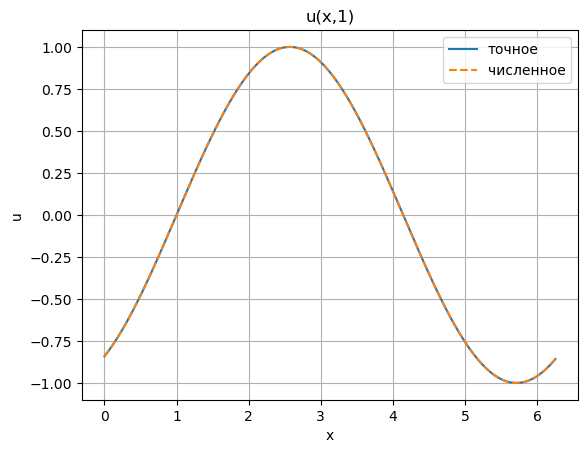

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def crank_nicolson(a, T, M, N, f=None, phi=None):
    L = 2*np.pi
    h = L/M
    τ = T/N
    β = a * τ/(4*h)
    # строим циклическую трёхдиагональную матрицу A
    A = np.zeros((M, M))
    for k in range(M):
        A[k,k]       = 1.0
        A[k,(k+1)%M] =  β
        A[k,(k-1)%M] = -β
    x = np.linspace(0, L, M, endpoint=False)
    u = phi(x) if phi is not None else np.zeros(M)
    for n in range(N):
        t = n*τ
        if f is None:
            rhs = u - β*(np.roll(u,-1) - np.roll(u,1))
        else:
            rhs = (u
                   - β*(np.roll(u,-1) - np.roll(u,1))
                   + 0.5*τ*(f(t+τ, x) + f(t, x)))
        u = np.linalg.solve(A, rhs)
    return x, u

# 1) Устойчивость (фон Неймана)
a, T, M0, N0 = 1.0, 1.0, 100, 100
h = (2*np.pi)/M0
τ = T/N0
μ = a*τ/(4*h)
q = np.linspace(0, 2*np.pi, 500)
G = (1 - 2j*μ*np.sin(q)) / (1 + 2j*μ*np.sin(q))
print("Максимум амплификационного множителя |G(q)| =", np.max(np.abs(G)))

# 2) Аппроксимация (численный порядок)
M_list = [50, 100, 200, 400]
errs = []
for M in M_list:
    x, u_num = crank_nicolson(a, T, M, M, phi=lambda x: np.sin(x))
    u_ex = np.sin(x - T)
    errs.append(np.max(np.abs(u_num - u_ex)))
for i in range(len(M_list)-1):
    rate = np.log2(errs[i]/errs[i+1])
    print(f"M={M_list[i]}→{M_list[i+1]}, err={errs[i]:.2e}→{errs[i+1]:.2e}, rate≈{rate:.2f}")

# 3) Численное решение для u_t+u_x=0, u(0,x)=sin(x)
M, N = 200, 200
x, u_num = crank_nicolson(a, T, M, N, phi=lambda x: np.sin(x))
u_ex = np.sin(x - T)
err = np.abs(u_num - u_ex)
print(f"\nМаксимальная абсолютная погрешность: {err.max():.2e}")
print("Первые 10 узлов (x, num, exact, err):")
for xi, un, ue in zip(x[:10], u_num[:10], u_ex[:10]):
    print(f"{xi:6.3f} {un:8.5f} {ue:8.5f} {abs(un-ue):8.2e}")

plt.figure()
plt.plot(x, u_ex,     label="точное")
plt.plot(x, u_num, '--', label="численное")
plt.title("u(x,1)")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.grid()
plt.show()


# 2


Рассматриваем уравнение  
$$
u_t - a^2(x,t)\,u_{xx} = 0,
\qquad
u(x,0)=\psi(x),
\quad -\infty<x<\infty.
$$  
По принципу «замороженных коэффициентов» фиксируем в анализе точку $(x_0,t_0)$ и считаем $a^2=a^2(x_0,t_0)$ постоянным.

---

## 1. Разностные схемы

### 1.1. FTCS (явная)
$$
\frac{u_k^{n+1}-u_k^n}{\tau}
\;-\;
a^2\,\frac{u_{k+1}^n - 2u_k^n + u_{k-1}^n}{h^2}
=0.
$$

### 1.2. BTCS (неявная)
$$
\frac{u_k^{n+1}-u_k^n}{\tau}
\;-\;
a^2\,\frac{u_{k+1}^{n+1} - 2u_k^{n+1} + u_{k-1}^{n+1}}{h^2}
=0.
$$

---

## 2. Аппроксимация

В обеих схемах локальная погрешность равна  
$$
O(\tau + h^2).
$$

---

## 3. Спектральный анализ (фон Неймана)

Ищем решение вида  
$$
u_k^n = G^n e^{i k \xi h}.
$$  
Обозначим  
$$
\theta = \xi h,
\qquad
r = \frac{a^2\,\tau}{h^2}.
$$

### 3.1. FTCS

Подстановка даёт
$$
G = 1 - 4\,r\,\sin^2\!\frac\theta2.
$$  
Условие $\lvert G\rvert\le1\ \forall\theta$ даёт
$$
0<r\le \tfrac12
\quad\Longleftrightarrow\quad
\tau \le \frac{h^2}{2\,a^2}.
$$  
**Итого:** схема **условно устойчива**.

### 3.2. BTCS

Подстановка даёт
$$
G = \frac{1}{1 + 4\,r\,\sin^2\!\frac\theta2},
$$  
и явно $\lvert G\rvert<1$ при любых $r>0$.  
**Итого:** схема **неусловно устойчива**.

---

## 4. Выводы

- **Аппроксимация:** $O(\tau + h^2)$ (1-й порядок по $t$, 2-й по $x$).  
- **Устойчивость:**
  - **FTCS:** условная,  
    $$\tau \le \frac{h^2}{2\,a^2(x_0,t_0)}.$$
  - **BTCS:** неусловная, для любых $\tau,h$.  

По принципу замороженных коэффициентов эти результаты переносятся на полную задачу с переменными коэффициентами $a^2(x,t)$.


# 3

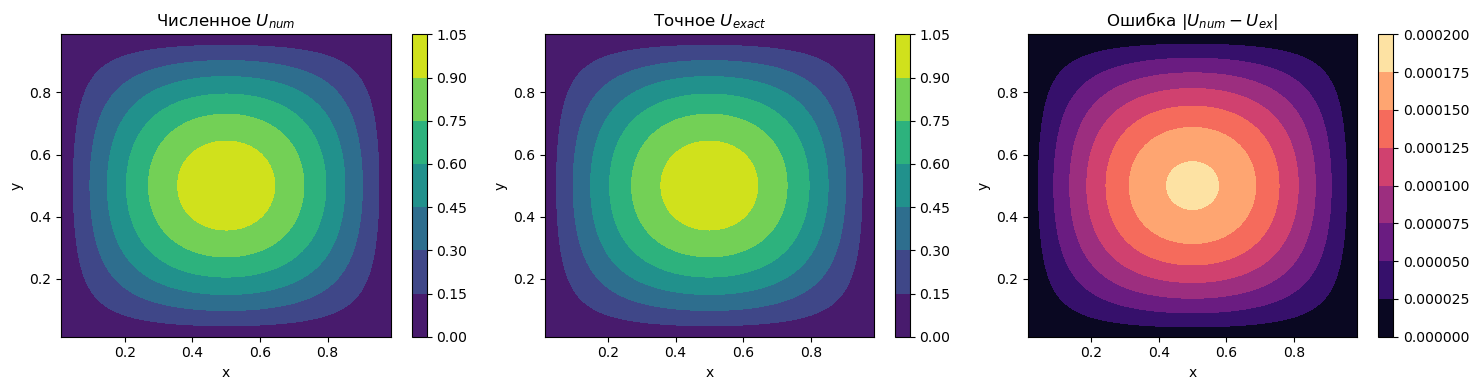

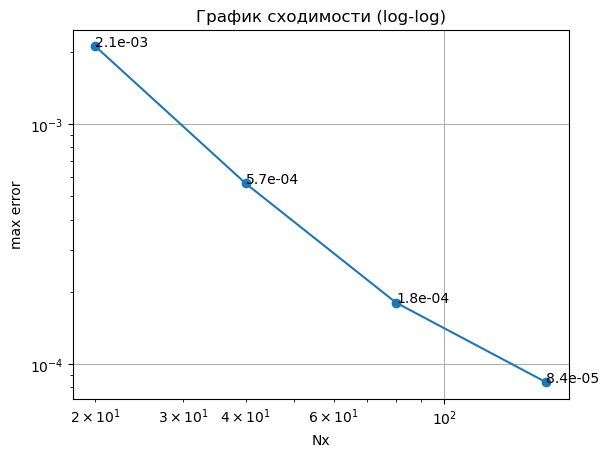

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def adi_heat(f, psi, T, Nx, Nt):
    h = 1.0/Nx; tau = T/Nt; alpha = tau/2; r = alpha/h**2
    n = Nx-1
    xs = np.linspace(h,1-h,n); ys = xs
    X,Y = np.meshgrid(xs,ys,indexing='ij')
    U = psi(X,Y)
    a = np.full(n-1, -r); b = np.full(n, 1+2*r); c = a.copy()
    cp = np.zeros(n-1)
    cp[0] = c[0]/b[0]
    for i in range(1,n-1):
        cp[i] = c[i]/(b[i] - a[i-1]*cp[i-1])
    def solve_tridiag(d):
        dp = np.zeros(n)
        dp[0] = d[0]/b[0]
        for i in range(1,n):
            denom = b[i] - (a[i-1]*cp[i-1] if i-1<n-1 else 0)
            dp[i] = (d[i] - (a[i-1]*dp[i-1] if i-1>=0 else 0))/denom
        x = np.zeros(n)
        x[-1] = dp[-1]
        for i in range(n-2,-1,-1):
            x[i] = dp[i] - cp[i]*x[i+1]
        return x
    for k in range(Nt):
        t_n, t_np1 = k*tau, (k+1)*tau
        F_n   = f(X,Y,t_n)
        F_np1 = f(X,Y,t_np1)
        U_pad = np.pad(U, ((0,0),(1,1)), mode='constant')
        Uyy   = (U_pad[:,2:] - 2*U_pad[:,1:-1] + U_pad[:,:-2]) / h**2
        RHS1  = U + alpha*Uyy + alpha*F_n
        U_star= np.zeros_like(U)
        for j in range(n):
            U_star[:,j] = solve_tridiag(RHS1[:,j])
        U_pad  = np.pad(U_star, ((1,1),(0,0)), mode='constant')
        Uxx    = (U_pad[2:,:] - 2*U_pad[1:-1,:] + U_pad[:-2,:]) / h**2
        RHS2   = U_star + alpha*Uxx + alpha*F_np1
        U_new  = np.zeros_like(U_star)
        for i in range(n):
            U_new[i,:] = solve_tridiag(RHS2[i,:])
        U = U_new
    return X, Y, U

def u_exact(x,y,t):
    return (1 - np.exp(-np.pi**2*t))*np.sin(np.pi*x)*np.sin(np.pi*y)

def f_rhs(x,y,t):
    return 2*np.pi**2 * np.sin(np.pi*x)*np.sin(np.pi*y)

# 1) Визуализация: выбираем сетку Nx=80
T = 1.0
Nx = 80; Nt = 80
X, Y, U_num = adi_heat(f_rhs, lambda X,Y: np.zeros_like(X), T, Nx, Nt)
U_ex = u_exact(X, Y, T)
err = np.abs(U_num - U_ex)

# Контурные графики
fig, axes = plt.subplots(1, 3, figsize=(15,4))
cs0 = axes[0].contourf(X, Y, U_num, cmap='viridis')
axes[0].set_title('Численное $U_{num}$')
fig.colorbar(cs0, ax=axes[0])
cs1 = axes[1].contourf(X, Y, U_ex, cmap='viridis')
axes[1].set_title('Точное $U_{exact}$')
fig.colorbar(cs1, ax=axes[1])
cs2 = axes[2].contourf(X, Y, err, cmap='magma')
axes[2].set_title('Ошибка $|U_{num}-U_{ex}|$')
fig.colorbar(cs2, ax=axes[2])
for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()

# 2) График сходимости (log-log)
mesh = [20, 40, 80, 160]
errors = []
for Nx in mesh:
    Nt = Nx
    X, Y, U_n = adi_heat(f_rhs, lambda X,Y: np.zeros_like(X), T, Nx, Nt)
    errors.append(np.max(np.abs(U_n - u_exact(X,Y,T))))

plt.figure()
plt.loglog(mesh, errors, '-o')
for i, e in enumerate(errors):
    plt.text(mesh[i], e, f'{e:.1e}')
plt.xlabel('Nx')
plt.ylabel('max error')
plt.title('График сходимости (log-log)')
plt.grid(True)
plt.show()


## 4


Рассматриваем уравнение  
$$
\frac{\partial}{\partial x}\bigl(u\,u_x\bigr)
+\frac{\partial}{\partial y}\bigl(u\,u_y\bigr)
=0
$$  
в прямоугольнике $0\le x\le X$, $0\le y\le Y$  
с граничными условиями  
$$
u(0,y)=1,\quad
u(x,0)=1,\quad
u(x,Y)=1+x^2,\quad
u(X,y)=1+\frac{X^2}{Y}\,y.
$$

---

## 1. Сетка и обозначения

- Разбиваем $[0,X]$ на $N_x$ шагов $h_x=X/N_x$,  
  и $[0,Y]$ на $N_y$ шагов $h_y=Y/N_y$.  
- Узлы $x_i=i\,h_x$, $i=0,\dots,N_x$,  
  $y_j=j\,h_y$, $j=0,\dots,N_y$.  
- Обозначаем $u_{i,j}\approx u(x_i,y_j)$.  
  На границе $u_{i,j}$ задаются из условий.

---

## 2. Нелинейная система

Для каждого внутреннего узла $(i,j)$, $1\le i\le N_x-1$, $1\le j\le N_y-1$, схема:

$$
\frac{1}{h_x^2}\Bigl[\tfrac{u_{i+1,j}+u_{i,j}}2\,(u_{i+1,j}-u_{i,j})
                  -\tfrac{u_{i,j}+u_{i-1,j}}2\,(u_{i,j}-u_{i-1,j})\Bigr]
+
\frac{1}{h_y^2}\Bigl[\tfrac{u_{i,j+1}+u_{i,j}}2\,(u_{i,j+1}-u_{i,j})
                  -\tfrac{u_{i,j}+u_{i,j-1}}2\,(u_{i,j}-u_{i,j-1})\Bigr]
=0.
$$

Всего $(N_x-1)(N_y-1)$ уравнений для тех же $(N_x-1)(N_y-1)$ неизвестных.

---

## 3. Метод Ньютона

Обозначим вектор $\mathbf U=\{u_{i,j}\}$. Составляем  
$$
\mathbf F(\mathbf U)=0,
$$  
где $F_{i,j}$ — левая часть дискретизации для узла $(i,j)$.  

**Итерации Ньютона**:
1. Начальное $\,\mathbf U^{(0)}\,$, например линейная интерполяция.  
2. Для $k=0,1,\dots$ пока $\|\mathbf F(\mathbf U^{(k)})\|$ велико:
   - Собрать якобиан $J^{(k)}_{pq}=\partial F_p/\partial U_q$.  
   - Решить $J^{(k)}\,\Delta\mathbf U = -\mathbf F(\mathbf U^{(k)})$.  
   - Обновить $\mathbf U^{(k+1)}=\mathbf U^{(k)}+\Delta\mathbf U$.  
3. Получим решение с невязкой $\|\mathbf F\|\approx10^{-8}$.

---


## 4. Выводы

- **Аппроксимация:** второй порядок, $O(h_x^2+h_y^2)$.  
- **Линейность:** схема – **нелинейная** (есть $u\,u$).  



In [10]:
import numpy as np

def newton_solve(X, Y, Nx, Ny, tol=1e-8, max_it=20):
    hx = X/(Nx-1); hy = Y/(Ny-1)
    x = np.linspace(0, X, Nx)
    y = np.linspace(0, Y, Ny)

    U = np.zeros((Nx, Ny))
    U[:, 0]   = 1.0
    U[0, :]   = 1.0
    U[:, -1]  = 1 + x**2
    U[-1, :]  = 1 + (X**2/Y)*y
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            U[i,j] = 1 + (x[i]**2/Y) * y[j]

    nxi, nyi = Nx-2, Ny-2
    N = nxi * nyi

    def idx(i, j):
        return (i-1) * nyi + (j-1)

    for it in range(max_it):
        F = np.zeros(N)
        J = np.zeros((N, N))
        for i in range(1, Nx-1):
            for j in range(1, Ny-1):
                k = idx(i, j)
                ui = U[i, j]
                u_ip = U[i+1, j]; u_im = U[i-1, j]
                u_jp = U[i, j+1]; u_jm = U[i, j-1]
                A = 0.5*(u_ip + ui); B = 0.5*(ui + u_im)
                C = 0.5*(u_jp + ui); D = 0.5*(ui + u_jm)
                F[k] = (A*(u_ip-ui) - B*(ui-u_im))/hx**2 + \
                       (C*(u_jp-ui) - D*(ui-u_jm))/hy**2
                # diagonal
                J[k, k] = (-A - B)/hx**2 + (-C - D)/hy**2
                # neighbors
                if i < Nx-2:
                    kp = idx(i+1, j)
                    J[k, kp] =  A/hx**2 + (u_ip-ui)/(2*hx**2)
                if i > 1:
                    km = idx(i-1, j)
                    J[k, km] =  B/hx**2 - (ui-u_im)/(2*hx**2)
                if j < Ny-2:
                    jp = idx(i, j+1)
                    J[k, jp] =  C/hy**2 + (u_jp-ui)/(2*hy**2)
                if j > 1:
                    jm = idx(i, j-1)
                    J[k, jm] =  D/hy**2 - (ui-u_jm)/(2*hy**2)
        delta = np.linalg.solve(J, -F)
        maxd = np.max(np.abs(delta))
        # update U
        for i in range(1, Nx-1):
            for j in range(1, Ny-1):
                U[i, j] += delta[idx(i, j)]
        if maxd < tol:
            print(f"Newton converged in {it+1} iters, max update = {maxd:.2e}")
            return U
    raise RuntimeError("Newton did not converge")

X, Y = 1.0, 1.0
Nx, Ny = 21, 21
U_sol = newton_solve(X, Y, Nx, Ny)

j_mid = Ny//2
x = np.linspace(0, X, Nx)
print("Solution at y=0.5:")
for i in range(0, Nx, 5):
    print(f"x={x[i]:.2f}, u={U_sol[i, j_mid]:.6f}")


Newton converged in 5 iters, max update = 7.36e-10
Solution at y=0.5:
x=0.00, u=1.000000
x=0.25, u=1.105219
x=0.50, u=1.226313
x=0.75, u=1.366142
x=1.00, u=1.500000
